In [1]:
import zipfile
import os

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('mnist_png')

print("Extraction complete")
print(os.listdir('mnist_png'))

Extraction complete
['mnist_png']


In [2]:
print(os.listdir('mnist_png/mnist_png'))

['testing', 'training']


In [3]:
print(os.listdir('mnist_png/mnist_png/training'))

['6', '7', '2', '1', '5', '8', '4', '0', '9', '3']


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, Model

In [5]:
def load_mnist_png(base_path):
    images = []
    labels = []
    for label in sorted(os.listdir(base_path)):
        label_path = os.path.join(base_path, label)
        if os.path.isdir(label_path):
            for img_file in os.listdir(label_path):
                img_path = os.path.join(label_path, img_file)
                img = Image.open(img_path).convert('L')
                images.append(np.array(img))
                labels.append(int(label))
    return np.array(images), np.array(labels)

train_images, train_labels = load_mnist_png('mnist_png/mnist_png/training')
test_images, test_labels = load_mnist_png('mnist_png/mnist_png/testing')

print("Train shape:", train_images.shape)
print("Test shape:", test_images.shape)

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


In [6]:
# Normalize to [0, 1] and add channel dimension
x_train = train_images.astype('float32') / 255.0
x_test = test_images.astype('float32') / 255.0

# Reshape to (samples, 28, 28, 1) for the autoencoder
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


In [7]:
noise_factor = 0.4

x_train_noisy = x_train + noise_factor * np.random.normal(0, 1, x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(0, 1, x_test.shape)

# Clip values to stay in [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Noisy train shape:", x_train_noisy.shape)
print("Noisy test shape:", x_test_noisy.shape)

Noisy train shape: (60000, 28, 28, 1)
Noisy test shape: (10000, 28, 28, 1)


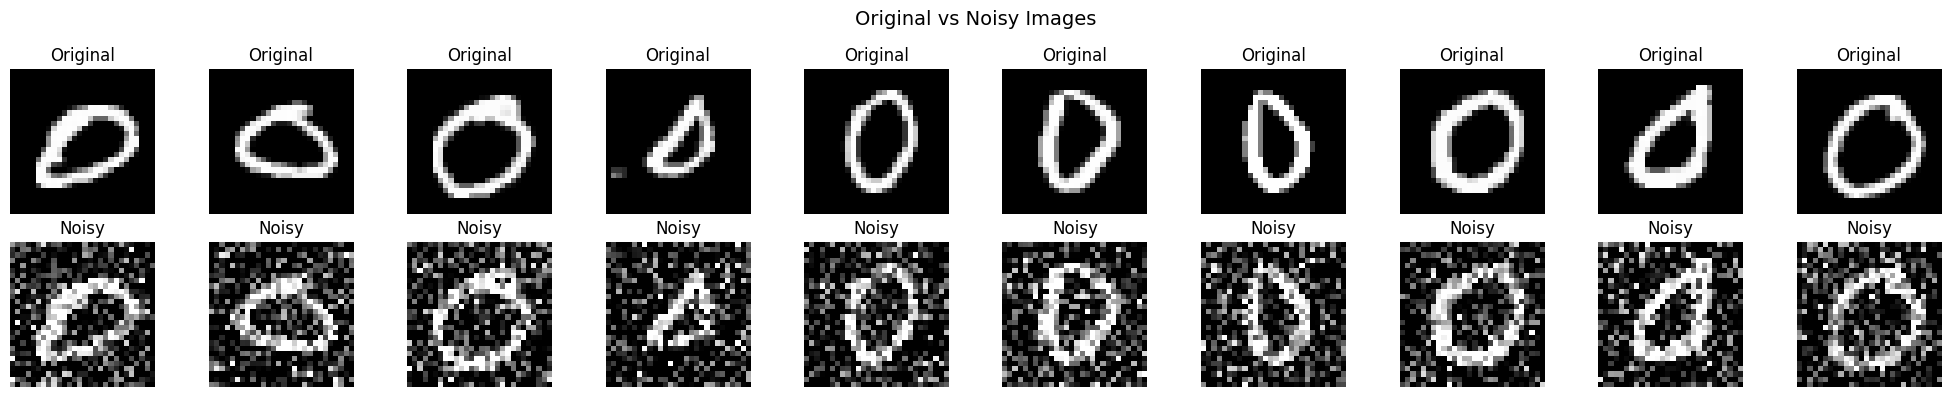

In [8]:
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(2, n, i + n + 1)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.suptitle("Original vs Noisy Images", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
def build_autoencoder():
    input_img = layers.Input(shape=(28, 28, 1))

    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = Model(input_img, decoded)
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 203s 427ms/step - loss: 0.1394 - val_loss: 0.0994
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 426ms/step - loss: 0.0966 - val_loss: 0.0935
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 209s 441ms/step - loss: 0.0924 - val_loss: 0.0901
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 256s 429ms/step - loss: 0.0903 - val_loss: 0.0885
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 426ms/step - loss: 0.0888 - val_loss: 0.0876
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 204s 431ms/step - loss: 0.0878 - val_loss: 0.0866
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 427ms/step - loss: 0.0871 - val_loss: 0.0861
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 424ms/step - loss: 0.0864 - val_loss: 0.0855
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 197s 420ms/step - loss: 0.0860 - val_loss: 0.0852
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 205s 426ms/step - loss: 0.0856 - val_loss: 0.0848


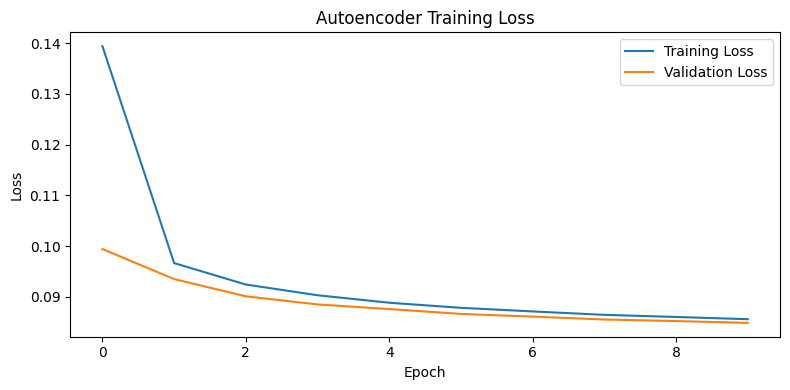

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
denoised_images = autoencoder.predict(x_test_noisy)
print("Denoised images shape:", denoised_images.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step
Denoised images shape: (10000, 28, 28, 1)


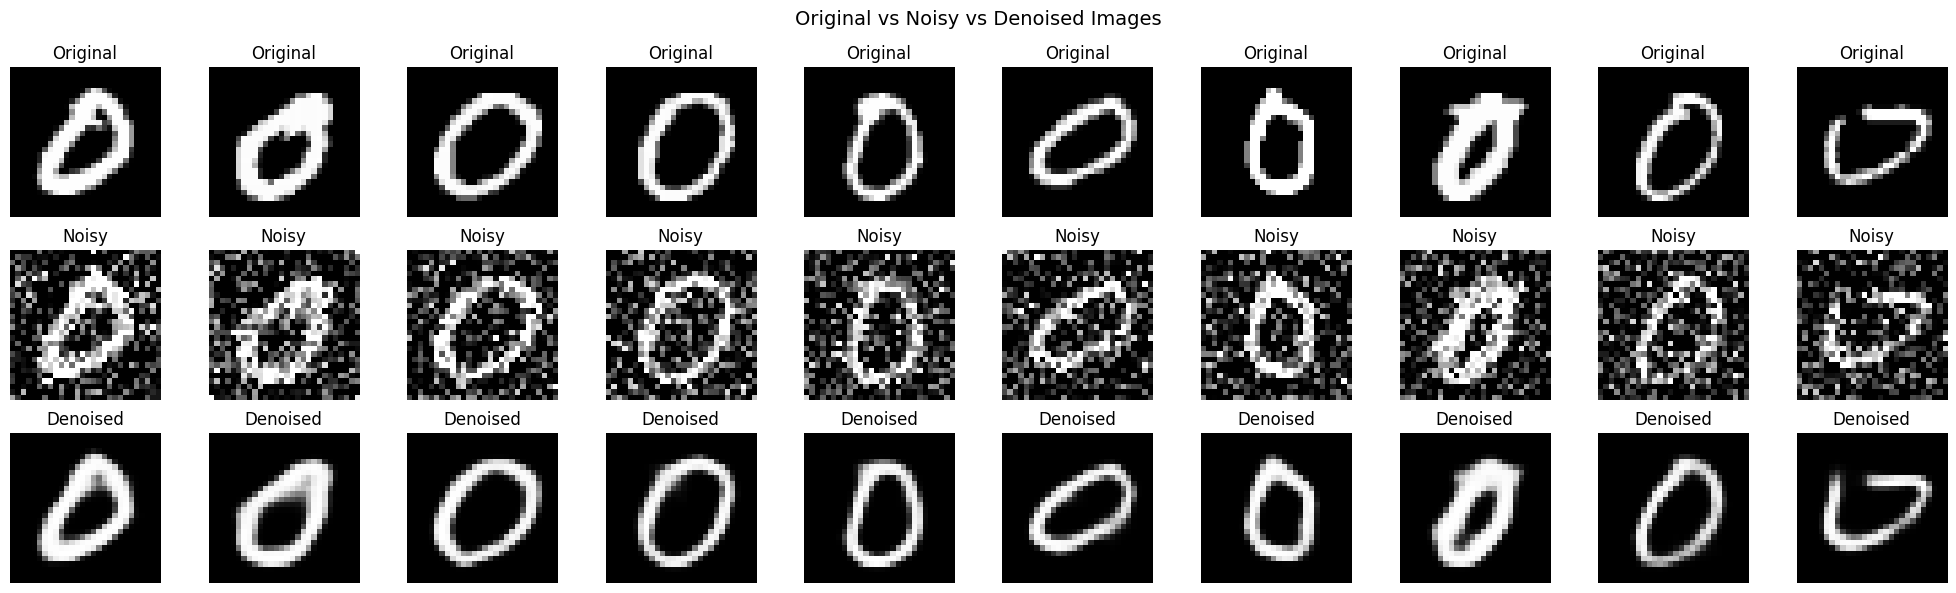

In [13]:
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(3, n, i + n + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3, n, i + 2*n + 1)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.suptitle("Original vs Noisy vs Denoised Images", fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
mse = np.mean(np.power(x_test - denoised_images, 2), axis=(1, 2, 3))
print("Mean MSE on test set:", np.mean(mse))
print("Min MSE:", np.min(mse))
print("Max MSE:", np.max(mse))

Mean MSE on test set: 0.007542075
Min MSE: 0.0010279282
Max MSE: 0.029812701


## Observations and Analysis

### Model Architecture
- Built a Convolutional Denoising Autoencoder with encoder-decoder structure.
- Encoder compresses 28x28 input down to 7x7 feature maps using Conv2D + MaxPooling.
- Decoder reconstructs back to 28x28 using Conv2D + UpSampling.
- Total trainable parameters: 74,497

### Training
- Optimizer: Adam
- Loss Function: Binary Crossentropy
- Epochs: 10, Batch Size: 128
- Both training and validation loss decreased steadily, indicating no overfitting.

### Denoising Performance
- The model successfully removed Gaussian noise (noise factor: 0.4) from digit images.
- Reconstructed images clearly preserve the digit structure.
- Mean MSE on test set: 0.0075, confirming strong denoising performance.

### Challenges
- Loading 70k PNG files individually is slow; future work could use TFRecords.
- Higher noise levels (>0.5) may require deeper architecture.

### Key Takeaway
- Denoising Autoencoders learn a compressed, noise-free representation of data,
  making them powerful for image restoration tasks.

In [15]:
from skimage.metrics import structural_similarity as ssim

ssim_scores = []
for i in range(len(x_test)):
    original = x_test[i].reshape(28, 28)
    denoised = denoised_images[i].reshape(28, 28)
    score = ssim(original, denoised, data_range=1.0)
    ssim_scores.append(score)

mean_ssim = np.mean(ssim_scores)
print("Mean SSIM on test set:", mean_ssim)

Mean SSIM on test set: 0.9084899293966818


## Innovation: SSIM Evaluation

- Added Structural Similarity Index (SSIM) as an additional evaluation metric.
- SSIM measures perceptual quality, capturing structural similarity better than MSE alone.
- Mean SSIM on test set: 0.908
- A score above 0.9 indicates the denoised images are highly similar to the originals.
- This confirms the autoencoder successfully preserves digit structure while removing noise.